# HALT Dataset - Exploratory Data Analysis
This notebook covers the exploratory data analysis for the Hand Leg Tongue (HALT) motor imagery dataset.

**Classes in the Dataset:**
* 1: Left Hand MI
* 2: Right Hand MI
* 3: Passive State
* 4: Left Leg MI
* 5: Tongue MI
* 6: Right Leg MI


In [1]:
import scipy.io as sio
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
data_dir = '/home/ezzo/PycharmProjects/condaEnv/HALT'
mat_files = [f for f in os.listdir(data_dir) if f.endswith('.mat')]
print(f"Discovered {len(mat_files)} MAT files.")

marker_mapping = {
    1: 'Left Hand',
    2: 'Right Hand',
    3: 'Passive',
    4: 'Left Leg',
    5: 'Tongue',
    6: 'Right Leg'
}

stats = []

for file in mat_files:
    subject_id = file.split('Subject')[1][0] if 'Subject' in file else 'Unknown'
    mat = sio.loadmat(os.path.join(data_dir, file))
    o = mat['o']
    marker = o[0,0]['marker'].flatten()
    
    for val, name in marker_mapping.items():
        starts = np.sum((marker[1:] == val) & (marker[:-1] != val))
        if marker[0] == val:
            starts += 1
            
        stats.append({
            'File': file,
            'Subject': subject_id,
            'Class': name,
            'Class_ID': val,
            'Instances': starts
        })

df_stats = pd.DataFrame(stats)
print("Data parsing complete.")


Discovered 29 MAT files.


Data parsing complete.


## Statistical Summary
Here we outline the number of motor imagery instances parsed from the markers.


In [3]:
subject_class_counts = df_stats.groupby(['Subject', 'Class'])['Instances'].sum().unstack(fill_value=0)
print("Instances per Class per Subject:")
display(subject_class_counts)


Instances per Class per Subject:


Class,Left Hand,Left Leg,Passive,Right Hand,Right Leg,Tongue
Subject,,,,,,
A,464,492,476,480,469,496
B,464,491,473,479,467,495
C,326,311,315,317,306,341
E,489,457,474,476,458,501
F,489,468,474,476,459,513
G,489,465,473,473,458,509
H,302,334,317,322,313,324
I,306,302,296,301,295,336
J,163,156,158,159,153,157


In [4]:
total_class_counts = df_stats.groupby('Class')['Instances'].sum().reset_index()
print("Total Instances per Class (across all subjects):")
display(total_class_counts)


Total Instances per Class (across all subjects):


,Class,Instances
0,Left Hand,4631
1,Left Leg,4564
2,Passive,4560
3,Right Hand,4593
4,Right Leg,4446
5,Tongue,4847


In [5]:
total_subj_counts = df_stats.groupby('Subject')['Instances'].sum().reset_index()
print("Total Instances per Subject (across all classes):")
display(total_subj_counts)


Total Instances per Subject (across all classes):


,Subject,Instances
0,A,2877
1,B,2869
2,C,1916
3,E,2855
4,F,2879
5,G,2867
6,H,1912
7,I,1836
8,J,946
9,K,1914


## Visualizations: Data Distribution


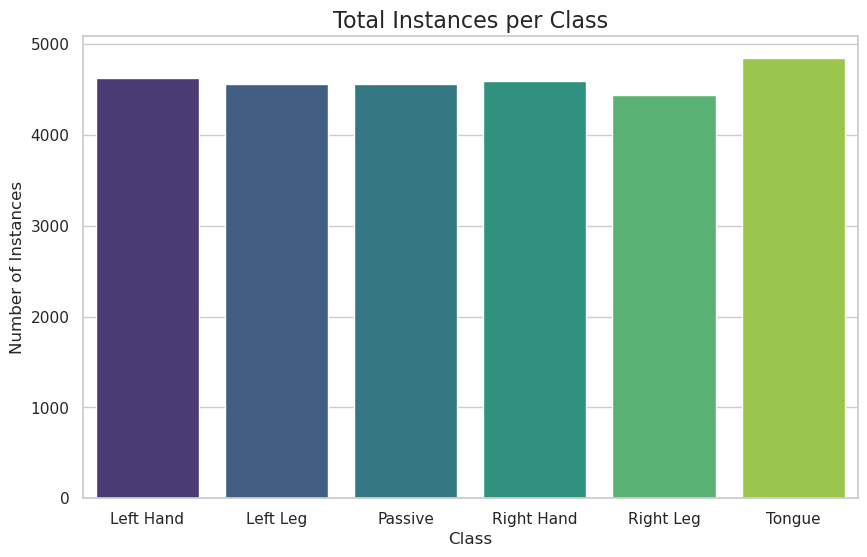

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=total_class_counts, x='Class', y='Instances', hue='Class', palette='viridis', legend=False)
plt.title('Total Instances per Class', fontsize=16)
plt.ylabel('Number of Instances')
plt.show()


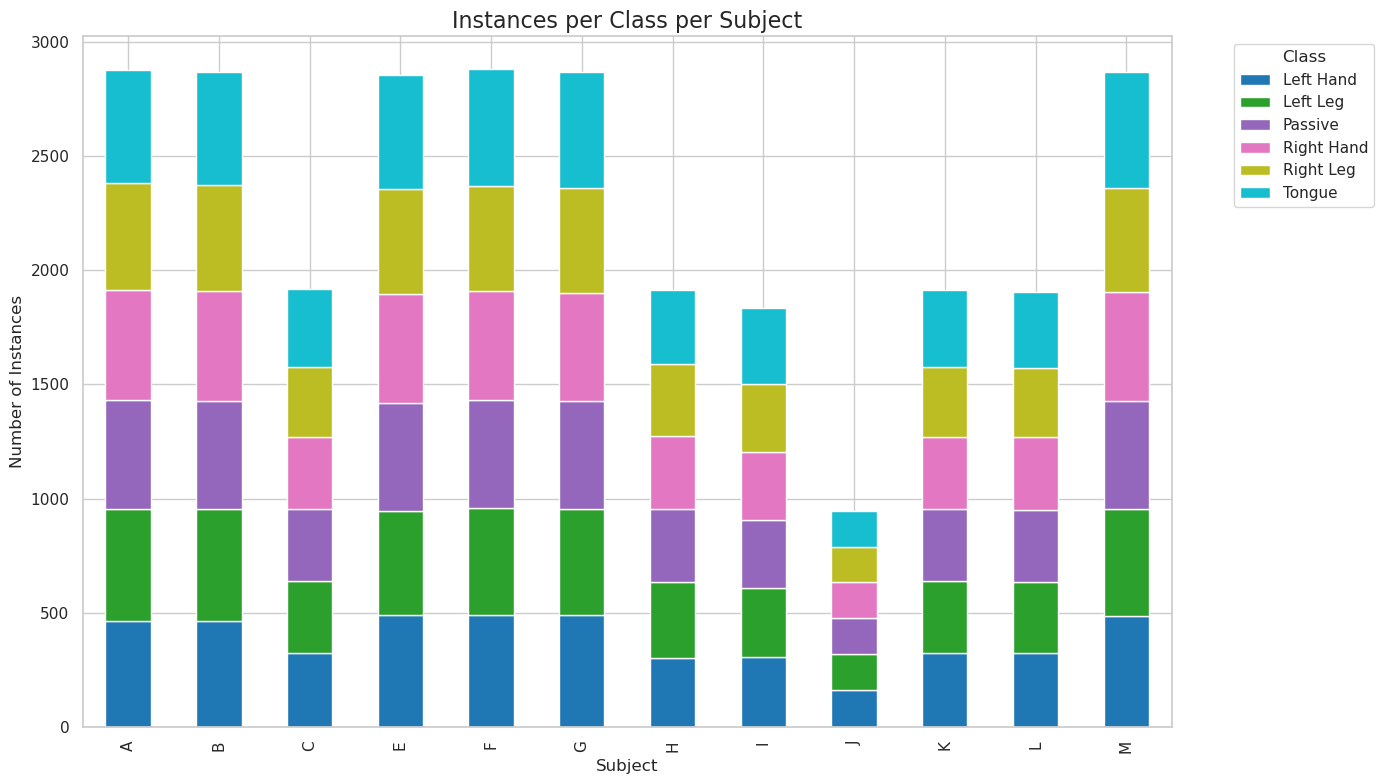

In [7]:
subject_class_counts.plot(kind='bar', stacked=True, colormap='tab10', figsize=(14, 8))
plt.title('Instances per Class per Subject', fontsize=16)
plt.ylabel('Number of Instances')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Visualizations: EEG Signals
Below, we plot one sample trial for each motor imagery class from the first subject's recording. We focus on the Central electrodes (C3, Cz, C4).


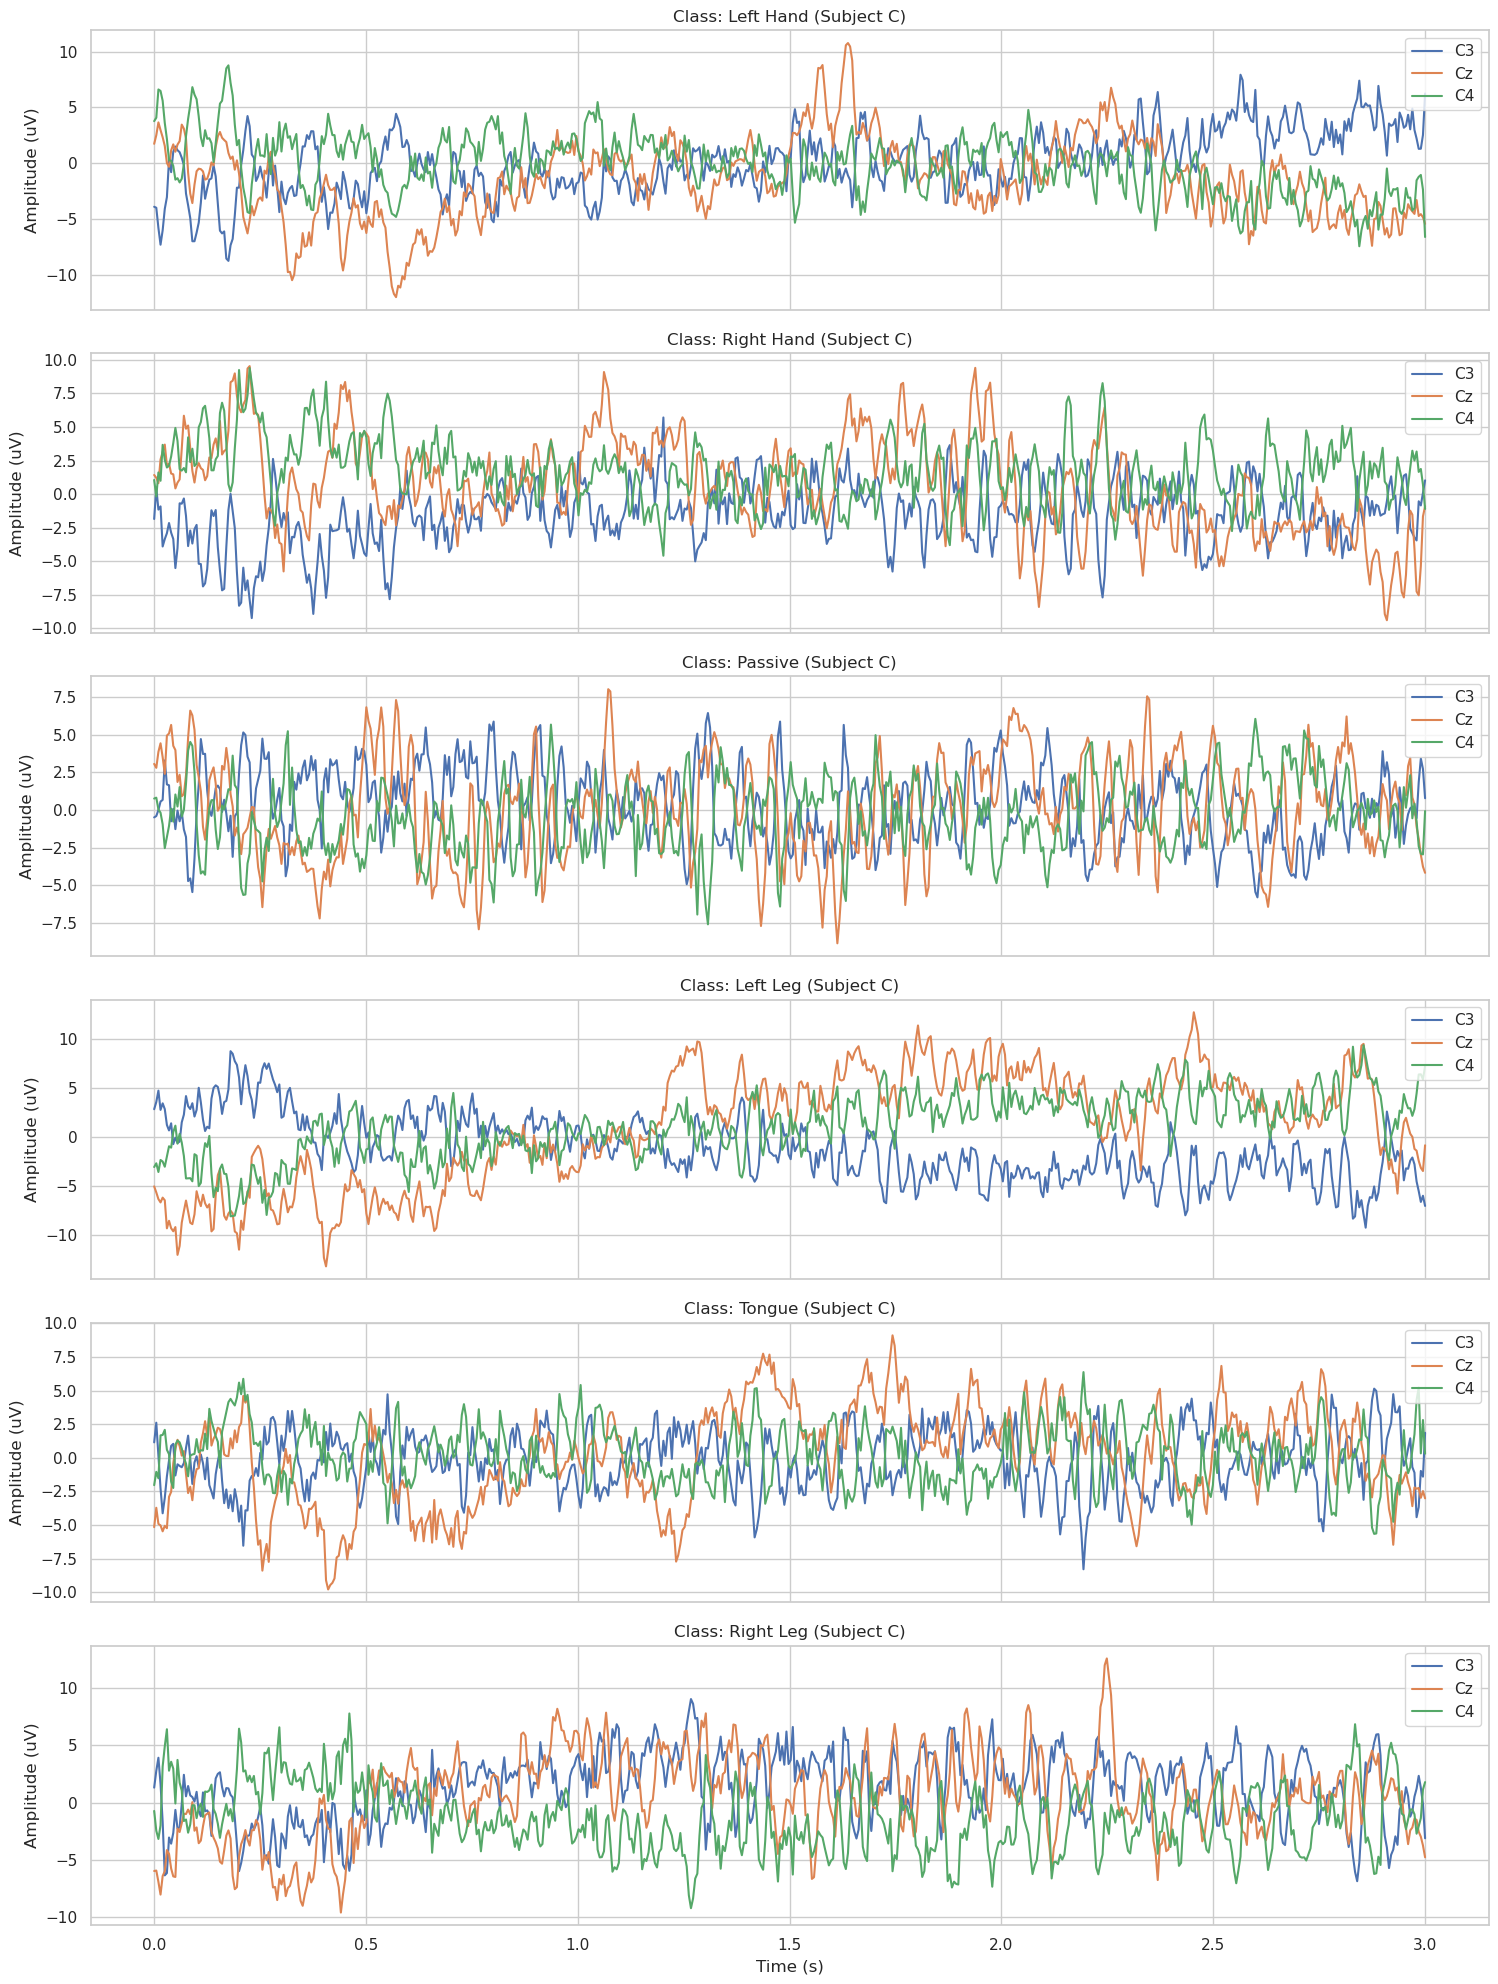

In [8]:
file_to_plot = mat_files[0]
mat = sio.loadmat(os.path.join(data_dir, file_to_plot))
o = mat['o']
data = o[0,0]['data']
marker = o[0,0]['marker'].flatten()
chnames = [ch[0][0] for ch in o[0,0]['chnames']]
sampFreq = int(o[0,0]['sampFreq'][0][0])

classes_to_plot = [1, 2, 3, 4, 5, 6]
fig, axes = plt.subplots(len(classes_to_plot), 1, figsize=(15, 20), sharex=True)

channels_to_plot = ['C3', 'Cz', 'C4']
ch_indices = [chnames.index(ch) for ch in channels_to_plot if ch in chnames]

for i, cls in enumerate(classes_to_plot):
    transitions = np.where((marker[1:] == cls) & (marker[:-1] != cls))[0]
    if len(transitions) > 0:
        start_idx = transitions[0]
        end_idx = start_idx + 3 * sampFreq # Next 3 seconds
        
        time_axis = np.linspace(0, 3, 3 * sampFreq)
        
        for ch_idx, ch_name in zip(ch_indices, channels_to_plot):
            axes[i].plot(time_axis, data[start_idx:end_idx, ch_idx], label=ch_name)
            
        axes[i].set_title(f"Class: {marker_mapping[cls]} (Subject {file_to_plot.split('Subject')[1][0]})")
        axes[i].legend(loc='upper right')
        axes[i].set_ylabel('Amplitude (uV)')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()
